# Food Insecurity and Meal Costs Analysis

This notebook investigates whether U.S. counties with lower food access have higher average meal costs. Analysis would include a permuation test and bootstrap confidence intervals.

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style = 'whitegrid')

## Data Loading and Cleaning portion

### Feeding America Map the Meal Gap (2025 Report - 2023 Data)
County-level food insecurity rates and meal costs. Filtered ot 2023 data only.
Source: https://www.feedingamerica.org/research/map-the-meal-gap

In [2]:
# Load Feeding America data
meal_gap = pd.read_excel('data/map_the_meal_gap.xlsx', sheet_name = 'County', header = 0)
# Filter 2023 items only
meal_gap = meal_gap[meal_gap['Year'] == 2023]
# Keeping it small and relevant - focused columns:
meal_gap = meal_gap[['FIPS', 'State', 'County, State', 'Year', 'Overall Food Insecurity Rate', 'Cost Per Meal']]

# renaming - some are too long
meal_gap = meal_gap.rename(columns = {
    'County, State': 'county_name',
    'Overall Food Insecurity Rate': 'food_insecurity_rate',
    'Cost per Meal': 'cost_per_meal'
})

print(meal_gap.shape)
print(meal_gap.head())
print(meal_gap.dtypes)

(3144, 6)
    FIPS State              county_name  Year  food_insecurity_rate  \
4   1001    AL  Autauga County, Alabama  2023                 0.151   
9   1003    AL  Baldwin County, Alabama  2023                 0.148   
14  1005    AL  Barbour County, Alabama  2023                 0.197   
19  1007    AL     Bibb County, Alabama  2023                 0.193   
24  1009    AL   Blount County, Alabama  2023                 0.173   

    Cost Per Meal  
4            3.64  
9            4.01  
14           3.45  
19           3.36  
24           3.36  
FIPS                      int64
State                       str
county_name                 str
Year                      int64
food_insecurity_rate    float64
Cost Per Meal           float64
dtype: object


### USDA Food Enviornment Atlas (2025)
County-level food access inidcators. PCT_LACCESS_POP19 (percentage of total population with low food access) and PTC_LACCESS_LOW19 (percentage of low-income population with low food access) from 2019; 2019 is the most recent year that is avaliable.

Source: https://www.ers.usda.gov/data-products/food-environment-atlas

In [3]:
# Load Food Environment Atlas - row 2 is headers
atlas = pd.read_excel('data/2025_Food_Atlas.xlsx', sheet_name = 'ACCESS', header = 1)

# Necessary Columns:
atlas = atlas[['FIPS', 'State', 'County', 'PCT_LACCESS_POP19', 'PCT_LACCESS_LOWI19']]

# Renaming
atlas = atlas.rename(columns = {
    'PCT_LACCESS_POP19': 'pct_low_access',
    'PCT_LACCESS_LOWI19': 'pct_low_access_lowincome'
})

# Drop missing values (-9999)
atlas = atlas[atlas['pct_low_access'] != -9999]
atlas = atlas[atlas['pct_low_access_lowincome'] != -9999]

print(atlas.shape)
print(atlas.head())
print(atlas.dtypes)



(3142, 5)
   FIPS State   County  pct_low_access  pct_low_access_lowincome
0  1001    AL  Autauga       33.906700                 13.020998
1  1003    AL  Baldwin       25.122238                  7.936779
2  1005    AL  Barbour       20.520679                 10.433171
3  1007    AL     Bibb        1.593457                  0.445866
4  1009    AL   Blount        6.807624                  2.512206
FIPS                          int64
State                           str
County                          str
pct_low_access              float64
pct_low_access_lowincome    float64
dtype: object


### Mergining the Datasets
FIPS county code - join key

In [4]:
# FIPS same in both dataframe before the merge
meal_gap['FIPS'] = meal_gap['FIPS'].astype(str).str.zfill(5)
atlas['FIPS'] = atlas['FIPS'].astype(str).str.zfill(5)

# merge
df = meal_gap.merge(atlas, on = 'FIPS', how = 'inner')
# drop the duplicate state column
df = df.drop(columns = ['State_y'])
df = df.rename(columns = {'State_x': 'State'})

print(df.shape)
print(df.head())
print(df.isnull().sum())

(3133, 9)
    FIPS State              county_name  Year  food_insecurity_rate  \
0  01001    AL  Autauga County, Alabama  2023                 0.151   
1  01003    AL  Baldwin County, Alabama  2023                 0.148   
2  01005    AL  Barbour County, Alabama  2023                 0.197   
3  01007    AL     Bibb County, Alabama  2023                 0.193   
4  01009    AL   Blount County, Alabama  2023                 0.173   

   Cost Per Meal   County  pct_low_access  pct_low_access_lowincome  
0           3.64  Autauga       33.906700                 13.020998  
1           4.01  Baldwin       25.122238                  7.936779  
2           3.45  Barbour       20.520679                 10.433171  
3           3.36     Bibb        1.593457                  0.445866  
4           3.36   Blount        6.807624                  2.512206  
FIPS                        0
State                       0
county_name                 0
Year                        0
food_insecurity_rate   

### Creating Low Access Groups
Counties in top quartile of pct_low_access = 'low access'. Counties that are BELOW the top quartile are marked as 'adequate access'

In [5]:
# low access threshold as top percentile
threshold = df['pct_low_access'].quantile(0.75)
print(f'Low access threshold (75th percentile): {threshold:.2f}%')

# Binary gorup column
df['access_group'] = np.where(df['pct_low_access'] >= threshold,
                              'Low Access',
                              'Adequate Access')

print(df['access_group'].value_counts())

Low access threshold (75th percentile): 32.37%
access_group
Adequate Access    2349
Low Access          784
Name: count, dtype: int64


### Dropping Null Values

In [6]:
# One single row with msising food insecurity rate
df = df.dropna(subset = ['food_insecurity_rate'])

print(f'Final dataset shape: {df.shape}')
print(f'Low Access counties: {(df["access_group"] == "Low Access").sum()}')
print(f'Adequate Access counties: {(df["access_group"] == "Adequate Access").sum()}')

Final dataset shape: (3132, 10)
Low Access counties: 784
Adequate Access counties: 2348


## Exploratory Data Analysis
### Statistics:

In [7]:
df = df.rename(columns = {'Cost Per Meal': 'cost_per_meal'})
# print(df.columns.tolist())

print('------ Cost per Meal -----')
df['cost_per_meal'] = df['cost_per_meal'].round(2)
print(df['cost_per_meal'].describe())

print('\n----- By Access Group ------')
print(df.groupby('access_group')['cost_per_meal'].describe())

print('\n----- Median Meal Cost by Group -----')
print(df.groupby('access_group')['cost_per_meal'].median())

------ Cost per Meal -----
count    3132.000000
mean        3.577739
std         0.346402
min         2.600000
25%         3.360000
50%         3.520000
75%         3.720000
max         6.090000
Name: cost_per_meal, dtype: float64

----- By Access Group ------
                  count      mean       std   min   25%   50%   75%   max
access_group                                                             
Adequate Access  2348.0  3.566167  0.346060  2.66  3.34  3.50  3.71  6.09
Low Access        784.0  3.612398  0.345331  2.60  3.41  3.57  3.76  5.05

----- Median Meal Cost by Group -----
access_group
Adequate Access    3.50
Low Access         3.57
Name: cost_per_meal, dtype: float64


### Distribution of Meal Costs by Access Group

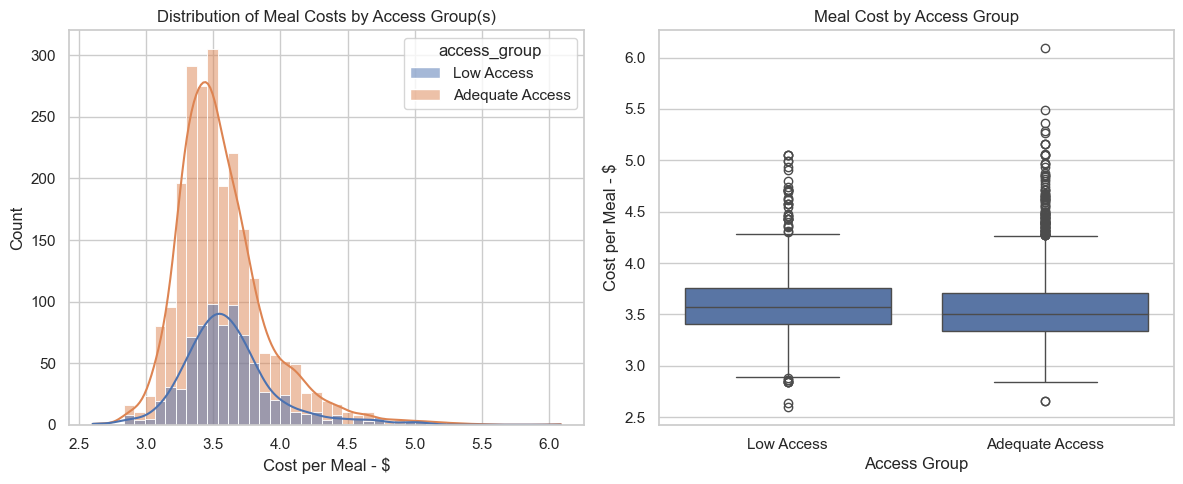

In [8]:
fig, axes = plt.subplots(1, 2, figsize = (12, 5))

# Histogram
sns.histplot(data = df, x = 'cost_per_meal', hue = 'access_group', bins = 45, kde = True, ax = axes[0])
axes[0].set_title('Distribution of Meal Costs by Access Group(s)')
axes[0].set_xlabel('Cost per Meal - $')
axes[0].set_ylabel('Count')

# Boxplot
sns.boxplot(data = df, x = 'access_group', y = 'cost_per_meal', ax = axes[1])
axes[1].set_title('Meal Cost by Access Group')
axes[1].set_xlabel('Access Group')
axes[1].set_ylabel('Cost per Meal - $')

plt.tight_layout()
plt.show()

### Scatter Plot - Low Access Rate vs Meal Cost

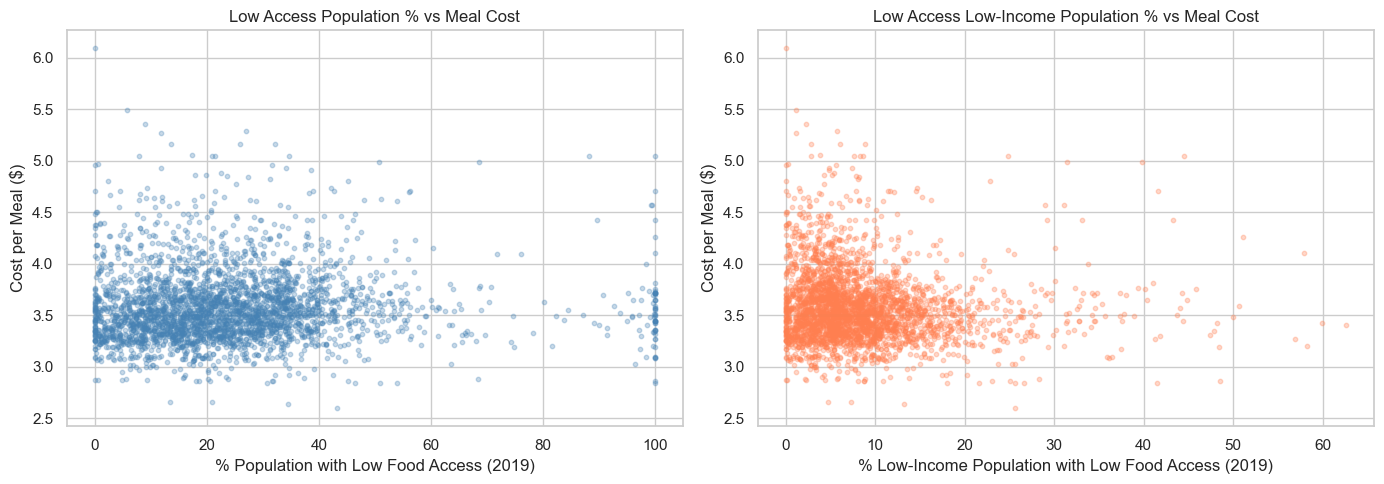

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PCT_LACCESS_POP19 vs meal cost
axes[0].scatter(df['pct_low_access'], df['cost_per_meal'], 
                alpha=0.3, s=10, color='steelblue')
axes[0].set_title('Low Access Population % vs Meal Cost')
axes[0].set_xlabel('% Population with Low Food Access (2019)')
axes[0].set_ylabel('Cost per Meal ($)')

# PCT_LACCESS_LOWI19 vs meal cost
axes[1].scatter(df['pct_low_access_lowincome'], df['cost_per_meal'], 
                alpha=0.3, s=10, color='coral')
axes[1].set_title('Low Access Low-Income Population % vs Meal Cost')
axes[1].set_xlabel('% Low-Income Population with Low Food Access (2019)')
axes[1].set_ylabel('Cost per Meal ($)')

plt.tight_layout()
plt.savefig('results/scatter_access_vs_meal_cost.png', dpi=150, bbox_inches='tight')
plt.show()

## Permuation Test

### Hypothesis
Null: There is no difference in median meal cost between low-access and adequate-access counties.

### Test Statistics
Difference in median meal costs = median(Low Access) - median(Adequate Access)

In [11]:
# observed test statistics
low_access = df[df['access_group'] == 'Low Access']['cost_per_meal']
adequate_access = df[df['access_group'] == 'Adequate Access']['cost_per_meal']

observed_diff = low_access.median() - adequate_access.median()
print(f'Observed median difference: ${observed_diff:.2f}')

Observed median difference: $0.07


In [ ]:
np.random.seed(50)
n_permutations = 10000
perm_diffs = []

for _ in range(n_permutations):
    # shuffle access group labels
    shuffled = df['access_group'].sample(frac = 1, replace = False).values

    # Recompute median difference under the null
    perm_low = df['cost_per_meal'][shuffled == 'Low Access'].median()
    perm_adequate = df['cost_per_meal'][shuffled == 'Adequate Access'].median()
    perm_diffs.append(perm_low - perm_adequate)

perm_diffs = np.array(perm_diffs)

# P-value
p_value = (perm_diffs >= observed_diff).mean()
print(f'Observed difference: ${observed_diff:.2f}')
print(f'P-value: {p_value:.4f}')


Observed difference: $0.07
P-value: 0.0000


### Null Distribution

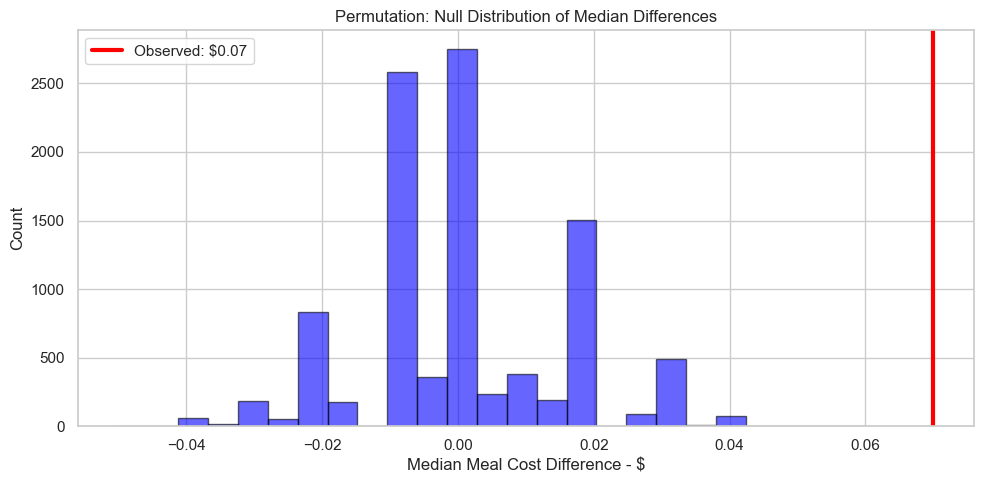

In [21]:
plt.figure(figsize = (10, 5))
plt.hist(perm_diffs, bins = 25, color = 'blue', edgecolor = 'black', alpha = 0.6)
plt.axvline(observed_diff, color = 'red', linewidth = 3, label = f'Observed: ${observed_diff:.3}')
plt.title('Permutation: Null Distribution of Median Differences')
plt.xlabel('Median Meal Cost Difference - $')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

## Bootstrap Confidence Intervals
### 1) Median Meal Cost Difference (Low Access - Adequate Access)
### 2) Correlation between Low Access rate and meal cost

In [ ]:
np.random.seed(50)
n_bootstrap = 10000
